In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.dpi']=150
plt.rcParams['font.family']='DejaVu Sans'

df=pd.read_csv('../data/zomato_cleaned.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (12037, 11)


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,listed_in(type),listed_in(city)
0,Byg Brewski Brewing Company,1,1,4.9,16832,Sarjapur Road,Microbrewery,"Continental, North Indian, Italian, South Indi...",1600.0,Dine-out,Sarjapur Road
1,Toit,0,0,4.7,14956,Indiranagar,Microbrewery,"Italian, American, Pizza",1500.0,Dine-out,Indiranagar
2,Truffles,0,0,4.7,14726,Koramangala 5th Block,"Cafe, Casual Dining","Cafe, American, Burger, Steak",900.0,Dine-out,Koramangala 7th Block


In [93]:
import os
os.makedirs('../visuals',exist_ok=True)
print('Visual folder ready')

Visual folder ready


## BQ1: Top 10 Areas by Average Rating python


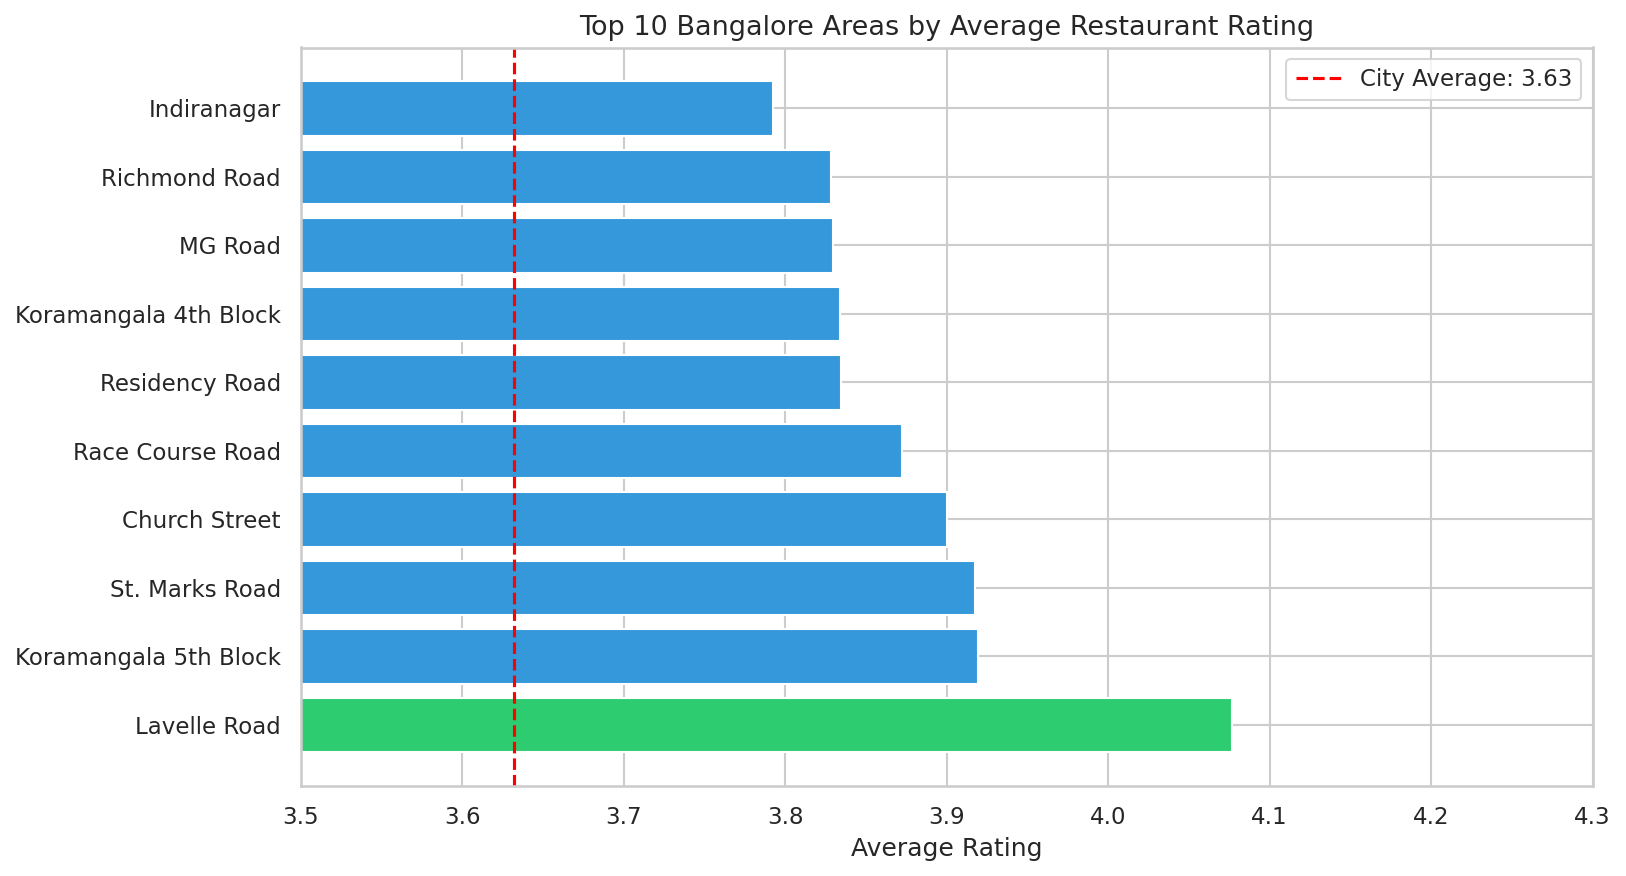

In [94]:
area_rating = df[df['rate'].notna()].groupby('location').agg(
    avg_rating=('rate', 'mean'),
    count=('name', 'count')
).reset_index()

area_rating = area_rating[area_rating['count'] >= 20].sort_values('avg_rating', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#2ecc71' if r >= 4.0 else '#3498db' for r in area_rating['avg_rating']]
bars = ax.barh(area_rating['location'], area_rating['avg_rating'], color=colors)

ax.set_title('Top 10 Bangalore Areas by Average Restaurant Rating', fontsize=13)
ax.set_xlabel('Average Rating')
ax.axvline(df['rate'].mean(), color='red', linestyle='--', 
           label=f'City Average: {df["rate"].mean():.2f}')
ax.legend()
ax.set_xlim(3.5, 4.3)

plt.tight_layout()
plt.savefig('../visuals/06_top_areas_rating.png', bbox_inches='tight')
plt.show()

## BQ2: Areas with Most Low-Rated Restaurants

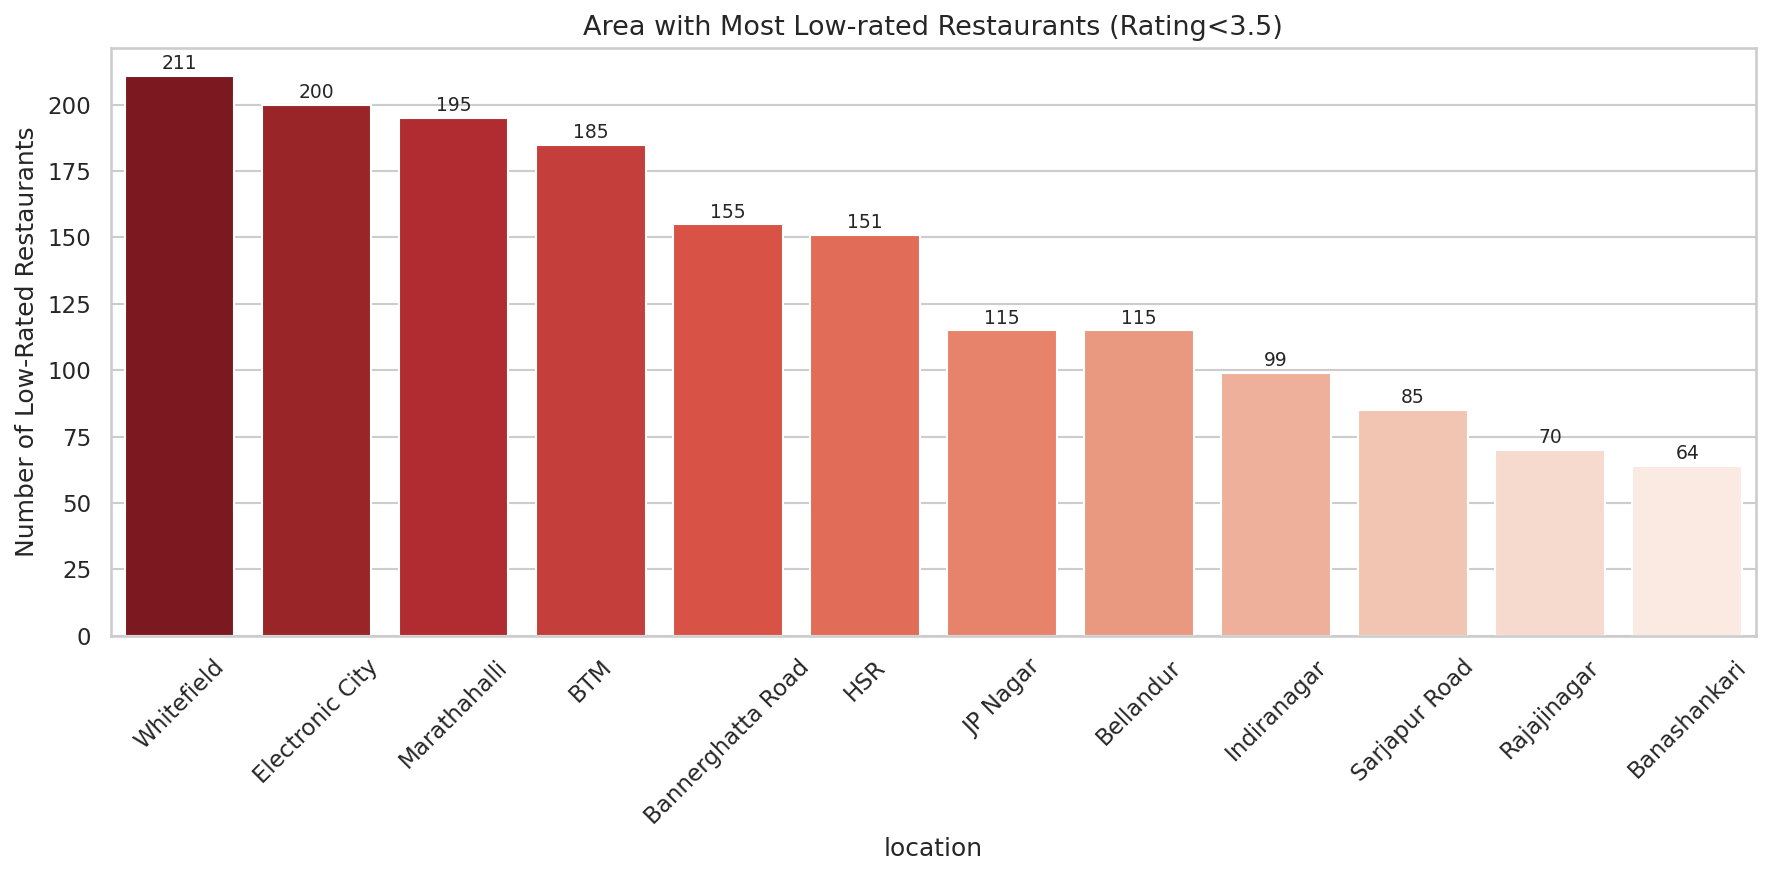

In [95]:
low_rated=df[df['rate']<3.5].groupby('location').size().reset_index(name='low_rated_count')
low_rated=low_rated[low_rated['low_rated_count']>= 20].sort_values('low_rated_count',ascending=False).head(12)
fig,ax=plt.subplots(figsize=(12,6))
bars=sns.barplot(data=low_rated,x='location',y='low_rated_count',palette='Reds_r',ax=ax)
ax.set_title('Area with Most Low-rated Restaurants (Rating<3.5)',fontsize=13)
ax.set_xlabel('location')
ax.set_ylabel('Number of Low-Rated Restaurants')
ax.tick_params(axis='x',rotation=45)

for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,str(int(bar.get_height())),
            ha='center',va='bottom',fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/02_low_rated_areas.png',bbox_inches='tight')
plt.show()

## BQ3: Price Range vs Rating (Boxplot)

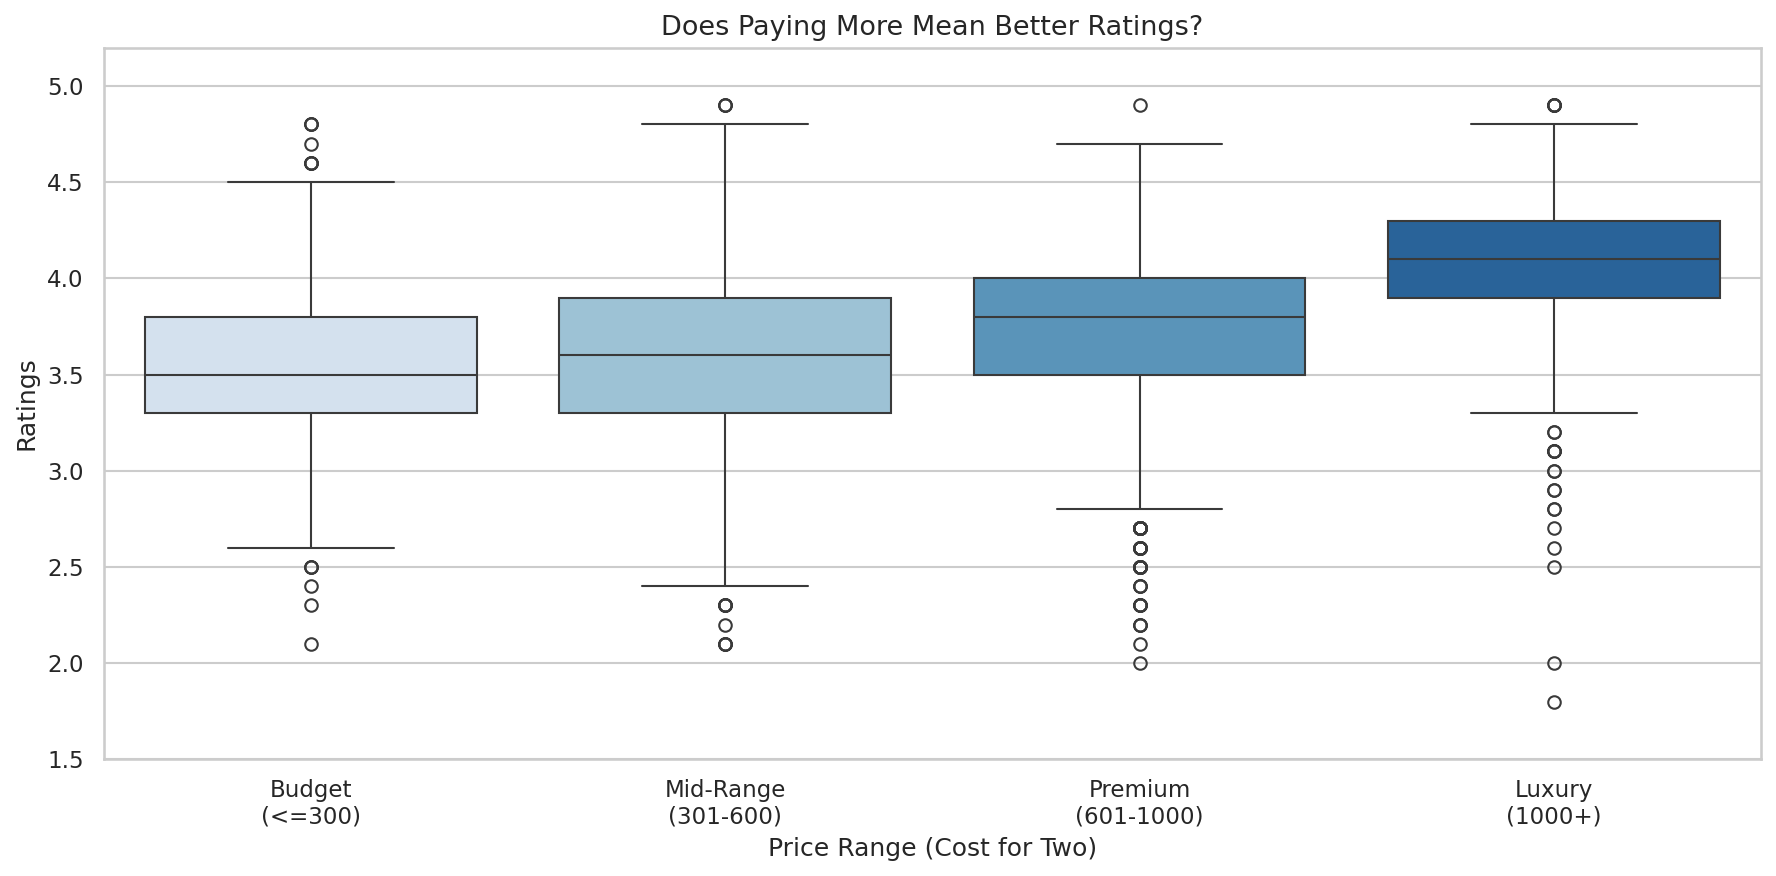

In [96]:
def price_category(cost):
    if cost <= 300: return 'Budget\n(<=300)'
    elif cost<=600: return 'Mid-Range\n(301-600)'
    elif cost<=1000: return 'Premium\n(601-1000)'
    else: return 'Luxury\n(1000+)'

df['price_category']=df['cost_for_two'].apply(price_category)

order=['Budget\n(<=300)','Mid-Range\n(301-600)','Premium\n(601-1000)','Luxury\n(1000+)']

fig,ax=plt.subplots(figsize=(12,6))
sns.boxplot(data=df[df['rate'].notna()],x='price_category',y='rate',order=order,palette='Blues',ax=ax)
ax.set_title('Does Paying More Mean Better Ratings?',fontsize=13)
ax.set_xlabel('Price Range (Cost for Two)')
ax.set_ylabel('Ratings')
ax.set_ylim(1.5,5.2)

plt.tight_layout()
plt.savefig('../visuals/03_price_vs_rating.png',bbox_inches='tight')
plt.show()

## BQ4: Restaurant Type vs Votes

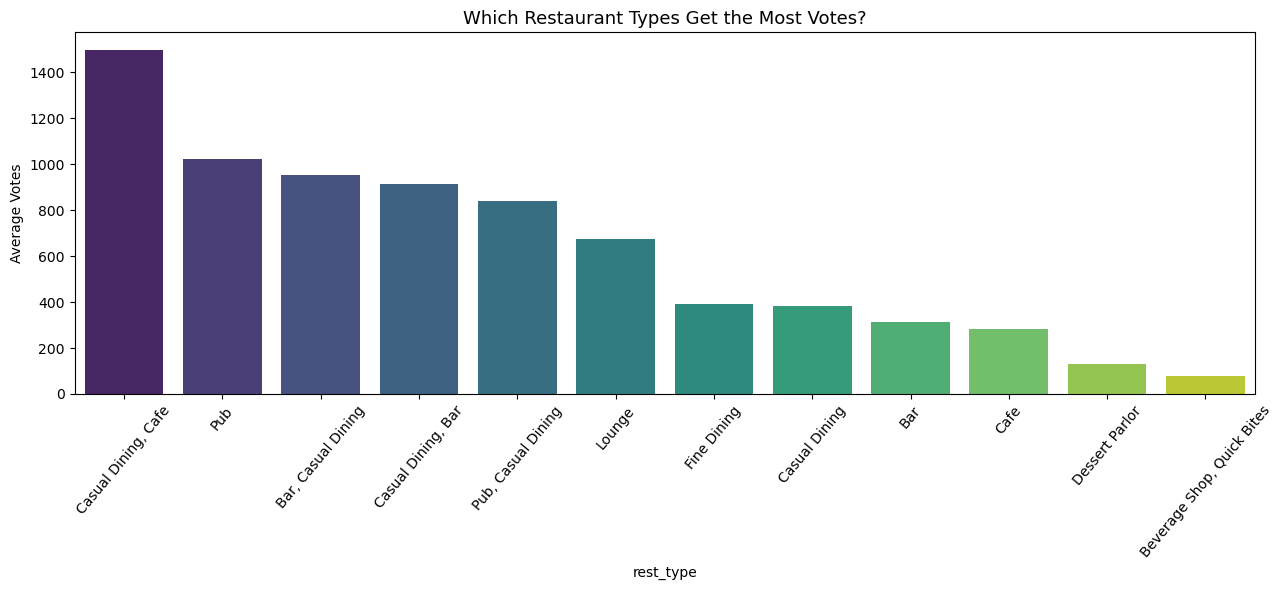

In [97]:
rest_votes=df.groupby('rest_type').agg(
    avg_votes=('votes','mean'),
    avg_rating=('rate','mean'),
    count=('name','count')).reset_index()
plt.style.use('default')
rest_votes=rest_votes[rest_votes['count']>=30].sort_values('avg_votes',ascending=False).head(12)
fig,ax=plt.subplots(figsize=(13,6))
sns.barplot(data=rest_votes,x='rest_type',y='avg_votes',palette='viridis',ax=ax)
ax.set_title('Which Restaurant Types Get the Most Votes?',fontsize=13)
ax.set_xlabel=('Restaurant Type')
ax.set_ylabel('Average Votes')
ax.tick_params(axis='x',rotation=50)
plt.tight_layout()
plt.savefig('../visuals/04_resttype_vs_votes.png',bbox_inches='tight')
plt.show()

## BQ4 Part 2: Popularity vs Quality Scatter (Most Impressive Chart)

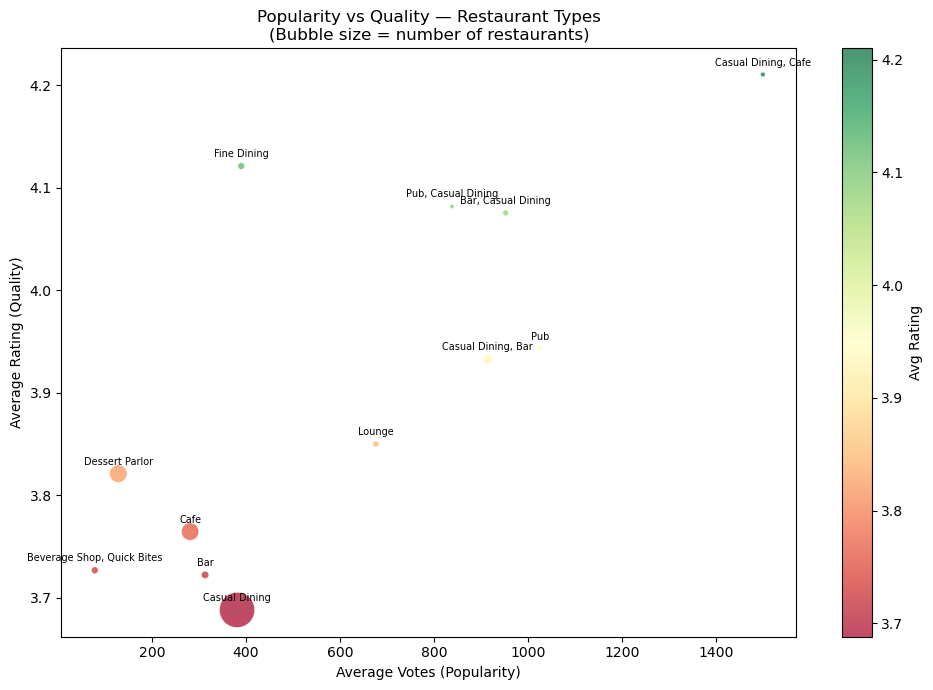

In [98]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    rest_votes['avg_votes'],
    rest_votes['avg_rating'],
    s=rest_votes['count'] * 0.3,   
    alpha=0.7,
    c=rest_votes['avg_rating'],
    cmap='RdYlGn',                  
    edgecolors='white',
    linewidths=0.5
)

for _, row in rest_votes.iterrows():
    ax.annotate(row['rest_type'], 
                (row['avg_votes'], row['avg_rating']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='Avg Rating')
ax.set_xlabel('Average Votes (Popularity)')
ax.set_ylabel('Average Rating (Quality)')
ax.set_title('Popularity vs Quality — Restaurant Types\n(Bubble size = number of restaurants)', fontsize=12)

plt.tight_layout()
plt.savefig('../visuals/05_popularity_vs_quality.png', bbox_inches='tight')
plt.show()

## BQ5: Rating Distribution Across the City

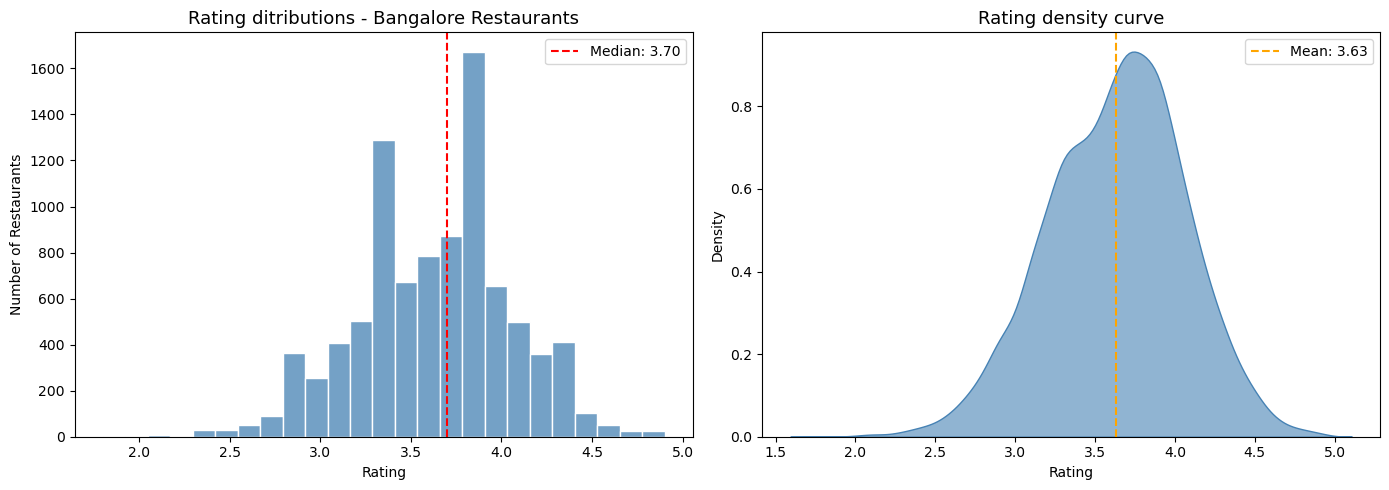

Mean: 3.63 | Meadian: 3.70


In [99]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
#Histogram
sns.histplot(df['rate'].dropna(),bins=25,color='steelblue',edgecolor='white',ax=axes[0])
axes[0].set_title('Rating ditributions - Bangalore Restaurants',fontsize=13)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Restaurants')
axes[0].axvline(df['rate'].median(), color='red', linestyle='--', 
                label=f"Median: {df['rate'].median():.2f}")
axes[0].legend()

# KDE (smooth distribution curve)
sns.kdeplot(df['rate'].dropna(),fill=True,color='steelblue',alpha=0.6,ax=axes[1])
axes[1].set_title('Rating density curve',fontsize=13)
axes[1].set_xlabel('Rating')
axes[1].axvline(df['rate'].mean(), color='orange', linestyle='--',
                label=f"Mean: {df['rate'].mean():.2f}")
axes[1].legend()
plt.tight_layout()
plt.savefig('../visuals/01_rating_distribution.png',bbox_inches='tight')
plt.show()
print(f"Mean: {df['rate'].mean():.2f} | Meadian: {df['rate'].median():.2f}")

## Correlatiion Heatmap

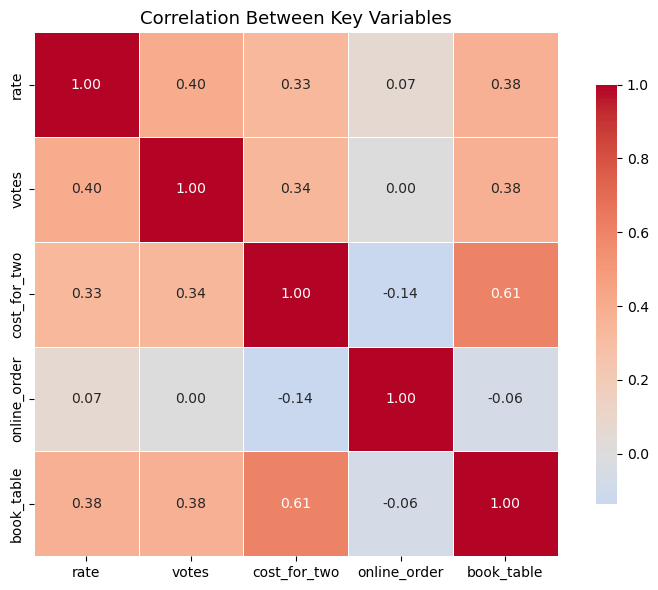

In [100]:
# Select only numeric columns that matter
numeric_cols = df[['rate', 'votes', 'cost_for_two', 'online_order', 'book_table']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Correlation Between Key Variables', fontsize=13)
plt.tight_layout()
plt.savefig('../visuals/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [101]:
print("=== KEY FINDINGS FROM EDA ===\n")
print(f"1. City average rating: {df['rate'].mean():.2f}")
print(f"2. Most low-rated area: {df[df['rate']<3.5]['location'].value_counts().index[0]}")
print(f"3. Highest rated area: {df[df['rate'].notna()].groupby('location')['rate'].mean().idxmax()}")
print(f"4. Luxury restaurants avg rating: {df[df['cost_for_two']>1000]['rate'].mean():.2f}")
print(f"5. Budget restaurants avg rating: {df[df['cost_for_two']<=300]['rate'].mean():.2f}")
print(f"6. % restaurants with online ordering: {df['online_order'].mean()*100:.1f}%")

=== KEY FINDINGS FROM EDA ===

1. City average rating: 3.63
2. Most low-rated area: Whitefield
3. Highest rated area: Lavelle Road
4. Luxury restaurants avg rating: 4.11
5. Budget restaurants avg rating: 3.55
6. % restaurants with online ordering: 52.1%
